# Spatial Heterogeneity Analysis

---

## Setup

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import sys, json, subprocess
import os
import tempfile

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import io
import imageio

from scipy.stats import mannwhitneyu

In [94]:
# ── project layout ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs/B2_exp_1_site_1_ERKKTR_ratio'

OUTPUT_ROOT.mkdir(exist_ok=True)

# ── spatiotemporal signal propagation graph construction parameters ────────────
EXP_ID        = 1
SITE_ID       = 1
SIGNAL_COL    = 'ERKKTR_ratio'
SPATIAL_RADIUS = 60
FUTURE_WINDOW  = 3
JUMP_QUANTILE  = 0.9

# ── helper: path to outputs for a given run ───────────────────────────────────
def output_dir(exp, site, signal=SIGNAL_COL):
    return OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}'

def load_summary(exp, site, signal=SIGNAL_COL):
    path = output_dir(exp, site, signal) / 'summary.json'
    with open(path) as f:
        return json.load(f)

print('Project root:', PROJECT_ROOT)
print('Data file exists:', DATA_PATH.exists())

Project root: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2
Data file exists: True


## Run

In [95]:
cmd = [
    sys.executable,
    str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
    '--data-path',           str(DATA_PATH),
    '--meta-path',           str(META_PATH),
    '--exp-id',              str(EXP_ID),
    '--site-id',             str(SITE_ID),
    '--signal-col',          SIGNAL_COL,
    '--spatial-radius',      str(SPATIAL_RADIUS),
    '--future-window-frames', str(FUTURE_WINDOW),
    '--jump-quantile',       str(JUMP_QUANTILE),
    '--output-dir',          str(OUTPUT_ROOT),
]

print('Running script …')
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Running script …

Spatiotemporal graph analysis complete.
Output directory: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2/analysis_outputs/B2_exp_1_site_1_ERKKTR_ratio/exp_1_site_1_ERKKTR_ratio
Mutation: WT
Nodes: 356,632
Spatial edges: 2,389,504
Temporal edges: 354,834
Jump threshold on ERKKTR_ratio: 0.0365
Interpretation of "jump": a large upward change since the previous frame.
Neighbour jump now means: at least one nearby cell shows such a large upward change at the current frame.
Future self jump means: the same cell shows such a large upward change within the next 3 frames.
Future jump rate with neighbour jump now: 0.13145546310189607
Future jump rate without neighbour jump now: 0.07486715044854579
Risk difference: 0.05658831265335028 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.7558496926130764 (times more likely; 1 means no difference, >1 means more likely).



## Nodes classification as edge" or "central"
### Set edge margin parameter
TODO algorithm description

In [97]:
EDGE_MARGIN_PERCENTILE = 5

In [98]:
nodes = pd.read_csv(output_dir(EXP_ID, SITE_ID) / 'nodes.csv.gz')

def classify_frame_edges(group):
    x_low = np.percentile(group['objNuclei_Location_Center_X'], EDGE_MARGIN_PERCENTILE)
    x_high = np.percentile(group['objNuclei_Location_Center_X'], 100 - EDGE_MARGIN_PERCENTILE)
    y_low = np.percentile(group['objNuclei_Location_Center_Y'], EDGE_MARGIN_PERCENTILE)
    y_high = np.percentile(group['objNuclei_Location_Center_Y'], 100 - EDGE_MARGIN_PERCENTILE)

    is_edge = (
        (group['objNuclei_Location_Center_X'] <= x_low) |
        (group['objNuclei_Location_Center_X'] >= x_high) |
        (group['objNuclei_Location_Center_Y'] <= y_low) |
        (group['objNuclei_Location_Center_Y'] >= y_high)
    )
    return np.where(is_edge, 'edge', 'central')

nodes['spatial_category'] = nodes.groupby('Image_Metadata_T').apply(
    lambda g: pd.Series(classify_frame_edges(g), index=g.index)
).reset_index(level=0, drop=True)

### A quick look on how groups are assigned

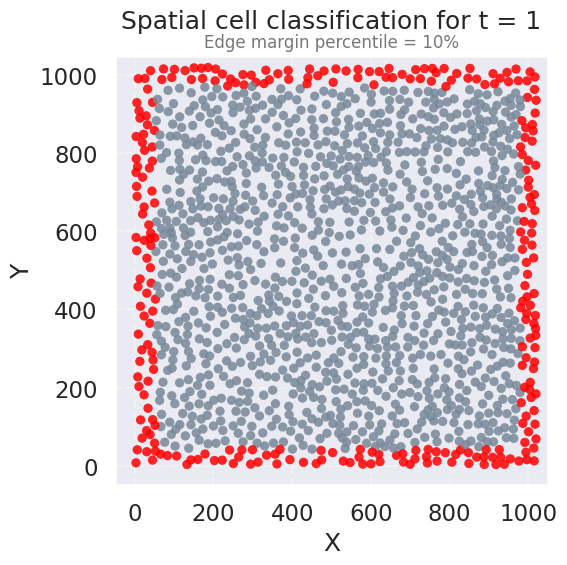

In [123]:
def spatial_classification_visualisation(snapshot):
    """Generates a scatter plot for a single time frame showing edge vs central cells."""
    # Extract the current time point directly from the snapshot data
    t = snapshot["Image_Metadata_T"].iloc[0]

    # Map colors based on the dynamic spatial category
    colors = np.where(
        snapshot["spatial_category"] == "edge", "red", "lightslategray"
    )

    # Initialize the plot with fixed square dimensions
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        snapshot["objNuclei_Location_Center_X"],
        snapshot["objNuclei_Location_Center_Y"],
        c=colors,
        s=45,
        alpha=0.85,
        edgecolor="none",
    )

    # Set rigid limits for X and Y axes to prevent jumping during animation
    ax.set_xlim(-50, 1050)
    ax.set_ylim(-50, 1050)

    # Main title with padding to make room for the subtitle
    ax.set_title(f"Spatial cell classification for t = {t}", pad=20)

    # Subtitle indicating the percentile used
    ax.text(0.5, 1.01, f"Edge margin percentile = {EDGE_MARGIN_PERCENTILE}%", transform=ax.transAxes,
        fontsize=12, color="#777777", ha="center", va="bottom",
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    return fig

snapshot_time = 1
snapshot = nodes[nodes["Image_Metadata_T"] == snapshot_time]
single_fig = spatial_classification_visualisation(snapshot)

#### Generate a gif for all t

In [122]:
# Sort time points to ensure chronological order in the GIF
time_points = sorted(nodes["Image_Metadata_T"].unique())
frames_images = []

print("Generating frames...")
for t in time_points:
    # Filter data for the current frame
    snapshot = nodes[nodes["Image_Metadata_T"] == t]

    if snapshot.empty:
        continue

    # 1. Call the standalone visualization function to create the figure
    fig = spatial_classification_visualisation(snapshot)

    # 2. Save the current figure directly to a memory buffer
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    buf.seek(0)

    # 3. Read the image from buffer and append to the frames list
    frames_images.append(imageio.v2.imread(buf))

    # 4. Close the plot to release memory immediately
    plt.close(fig)

# Save all gathered frames into an animated GIF
output_gif_path = "cell_propagation_boundaries.gif"
imageio.mimsave(output_gif_path, frames_images, fps=20, loop=0)

print(f"Done! Animated GIF successfully saved to: {output_gif_path}")

Generating frames...
Done! Animated GIF successfully saved to: cell_propagation_boundaries.gif


### Number of cells classificed to each category

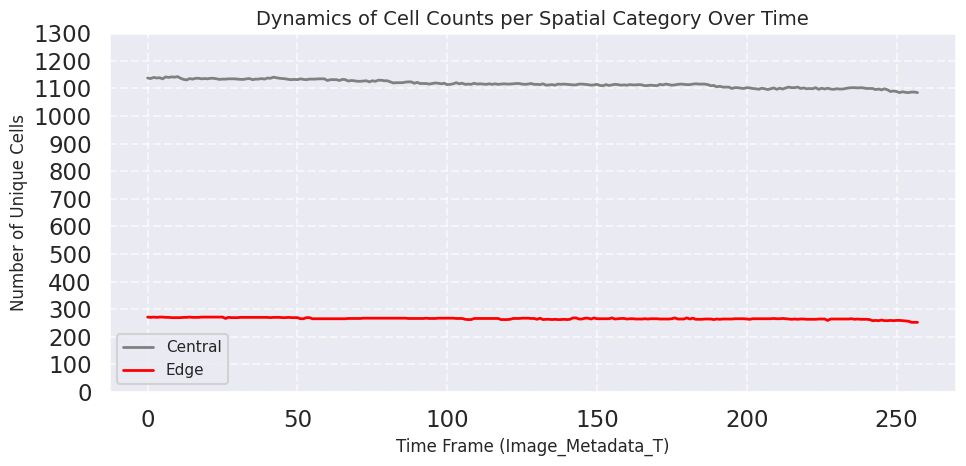

In [109]:
# We count unique track_ids at each time point (frame) for each spatial category
counts_per_frame = (
    nodes.groupby(["Image_Metadata_T", "spatial_category"])["track_id"]
    .nunique()
    .unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(10, 5))

# Plot central cells (gray)
ax.plot(
    counts_per_frame.index,
    counts_per_frame["central"],
    color="gray",
    linestyle="-",
    linewidth=2,
    label="Central",
)

# Plot edge cells (red)
ax.plot(
    counts_per_frame.index,
    counts_per_frame["edge"],
    color="red",
    linestyle="-",
    linewidth=2,
    label="Edge",
)

# Chart styling
ax.set_title("Dynamics of Cell Counts per Spatial Category Over Time", fontsize=14)
ax.set_xlabel("Time Frame (Image_Metadata_T)", fontsize=12)
ax.set_ylabel("Number of Unique Cells", fontsize=12)
ax.set_yticks(ticks = range(0, max(counts_per_frame["central"]) + 200,100))

ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="best", fontsize=11)

plt.tight_layout()
plt.show()

In [124]:
def calculate_propagation_metrics(df):
    """Calculates Exposed Rate, Unexposed Rate, Relative Risk (RR),

    and Risk Difference (RD) for a given nodes dataframe.
    """
    # Filter nodes into exposed (has jumping neighbor now) and unexposed
    exposed = df[df["neighbor_jump_now"] == True]
    unexposed = df[df["neighbor_jump_now"] == False]

    n_exposed = len(exposed)
    n_unexposed = len(unexposed)

    # Calculate probabilities of jumping in the near future (Outcome)
    p_exposed = exposed["future_self_jump"].mean() if n_exposed > 0 else np.nan
    p_unexposed = (
        unexposed["future_self_jump"].mean() if n_unexposed > 0 else np.nan
    )

    # Calculate Relative Risk (RR) and Risk Difference (RD)
    if pd.isna(p_exposed) or pd.isna(p_unexposed) or p_unexposed == 0:
        rr = np.nan
    else:
        rr = p_exposed / p_unexposed

    rd = p_exposed - p_unexposed if not (pd.isna(p_exposed) or pd.isna(p_unexposed)) else np.nan

    return {
        "n_exposed_nodes": n_exposed,
        "n_unexposed_nodes": n_unexposed,
        "p_exposed": p_exposed,
        "p_unexposed": p_unexposed,
        "RR": rr,
        "RD": rd,
    }

In [125]:
def generate_spatial_comparison_table(nodes_df):
    """Stratifies the nodes table by spatial_category and computes

    comparative statistics including unique cell counts, mean neighbors, and RR/RD.
    """
    comparison_rows = []

    # Group by spatial category (edge vs central)
    for category, sub_df in nodes_df.groupby("spatial_category"):
        # 1. Calculate propagation metrics using the function from Cell 1
        metrics = calculate_propagation_metrics(sub_df)

        # 2. Calculate spatial architecture metrics
        mean_neighbors = sub_df["neighbor_count"].mean()
        n_unique_cells = sub_df["track_id"].nunique()
        total_nodes = len(sub_df)

        # 3. Combine everything into a single row dictionary
        row = {
            "spatial_category": category,
            "unique_cells": n_unique_cells,
            "total_nodes": total_nodes,
            "mean_neighbors": mean_neighbors,
            "RR": metrics["RR"],
            "RD": metrics["RD"],
            "p_exposed": metrics["p_exposed"],
            "p_unexposed": metrics["p_unexposed"],
        }
        comparison_rows.append(row)

    # Create the final DataFrame
    comparison_table = pd.DataFrame(comparison_rows)

    # Optional: formatting for better readability in Jupyter
    columns_order = [
        "spatial_category",
        "unique_cells",
        "total_nodes",
        "mean_neighbors",
        "RR",
        "RD",
        "p_exposed",
        "p_unexposed",
    ]
    return comparison_table[columns_order]


# --- How to run it ---
# Assuming 'nodes' already has the 'spatial_category' column calculated
summary_table = generate_spatial_comparison_table(nodes)
display(summary_table)

,spatial_category,unique_cells,total_nodes,mean_neighbors,RR,RD,p_exposed,p_unexposed
0,central,1415,288148,14.067014,1.814384,0.057725,0.128606,0.070882
1,edge,529,68484,10.595555,1.610716,0.055072,0.145247,0.090176
